# Data audit: intraday returns and missingness

This notebook audits the dataset before any model is trained. It keeps observed zero returns distinct from missing observations.

---

## Panel structure audit

This section treats `day` as a panel identifier only. Its numerical properties are audited below, but no chronological ordering, calendar spacing, or temporal continuity is assumed.

In [1]:
from pathlib import Path
import itertools
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Open this notebook from the project or notebooks directory.')

sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import (
    ReturnPreprocessor,
    get_return_columns,
    load_training_data,
    summarize_missingness,
)

X_train, y_train = load_training_data(PROJECT_ROOT / 'data')
return_columns = get_return_columns(X_train.columns)
returns = X_train[return_columns]


N_DAYS = X_train['day'].nunique()
N_EQUITIES = X_train['equity'].nunique()
N_ROWS = len(X_train)
N_OBSERVED_PAIRS = X_train[['day', 'equity']].drop_duplicates().shape[0]
N_DUPLICATE_ROWS_PER_PAIR = N_ROWS - N_OBSERVED_PAIRS
PANEL_DENSITY = N_OBSERVED_PAIRS / (N_DAYS * N_EQUITIES)

panel_overview = pd.Series({
    'rows': N_ROWS,
    'unique_days': N_DAYS,
    'unique_equities': N_EQUITIES,
    'observed_day_equity_pairs': N_OBSERVED_PAIRS,
    'duplicate_rows_per_day_equity_pair': N_DUPLICATE_ROWS_PER_PAIR,
    'theoretical_day_equity_pairs': N_DAYS * N_EQUITIES,
    'observed_panel_density': PANEL_DENSITY,
}, name='value').to_frame()
display(panel_overview)

,value
rows,843299.000000
unique_days,503.000000
unique_equities,1829.000000
observed_day_equity_pairs,843299.000000
duplicate_rows_per_day_equity_pair,0.000000
theoretical_day_equity_pairs,919987.000000
observed_panel_density,0.916642


,observations_per_day,observations_per_equity,distinct_days_per_equity,equity_day_coverage
count,503.000000,1829.000000,1829.000000,1829.000000
mean,1676.538767,461.071077,461.071077,0.916642
std,16.061076,108.499712,108.499712,0.215705
min,1633.000000,3.000000,3.000000,0.005964
1%,1634.000000,36.000000,36.000000,0.071571
10%,1648.000000,304.400000,304.400000,0.605169
25%,1671.000000,503.000000,503.000000,1.000000
50%,1680.000000,503.000000,503.000000,1.000000
75%,1687.000000,503.000000,503.000000,1.000000
90%,1693.000000,503.000000,503.000000,1.000000


,value
equities_present_on_one_day,0.000000
share_equities_present_on_one_day,0.000000
equities_present_on_all_day_ids,1513.000000
share_equities_present_on_all_day_ids,0.827228


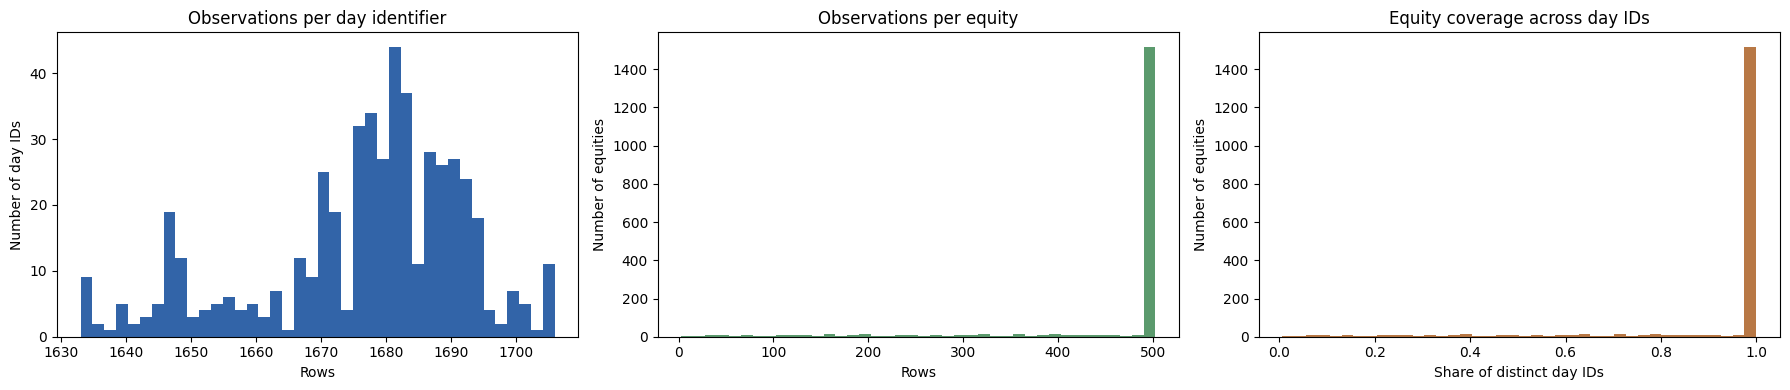

In [2]:
def compact_describe(values: pd.Series) -> pd.Series:
    return values.describe(percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])

observations_per_day = X_train.groupby('day').size().rename('observations')
observations_per_equity = X_train.groupby('equity').size().rename('observations')
days_per_equity = X_train.groupby('equity')['day'].nunique().rename('distinct_days')
equity_coverage = (days_per_equity / N_DAYS).rename('day_coverage')

entity_summary = pd.concat({
    'observations_per_day': compact_describe(observations_per_day),
    'observations_per_equity': compact_describe(observations_per_equity),
    'distinct_days_per_equity': compact_describe(days_per_equity),
    'equity_day_coverage': compact_describe(equity_coverage),
}, axis=1)
display(entity_summary)

coverage_summary = pd.Series({
    'equities_present_on_one_day': int((days_per_equity == 1).sum()),
    'share_equities_present_on_one_day': float((days_per_equity == 1).mean()),
    'equities_present_on_all_day_ids': int((days_per_equity == N_DAYS).sum()),
    'share_equities_present_on_all_day_ids': float((days_per_equity == N_DAYS).mean()),
}, name='value').to_frame()
display(coverage_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(observations_per_day, bins=40, color='#3264a8')
axes[0].set(title='Observations per day identifier', xlabel='Rows', ylabel='Number of day IDs')
axes[1].hist(observations_per_equity, bins=40, color='#5b9a6d')
axes[1].set(title='Observations per equity', xlabel='Rows', ylabel='Number of equities')
axes[2].hist(equity_coverage, bins=40, color='#b87845')
axes[2].set(title='Equity coverage across day IDs', xlabel='Share of distinct day IDs', ylabel='Number of equities')
plt.tight_layout()
plt.show()

Jaccard method: reproducible sample of 10,000 unordered day-ID pairs from 126,253 possible pairs (seed=20260908)


,jaccard_overlap
count,10000.000000
mean,0.938299
std,0.040897
min,0.838656
1%,0.848030
10%,0.877884
25%,0.907168
50%,0.943320
75%,0.973486
90%,0.989318


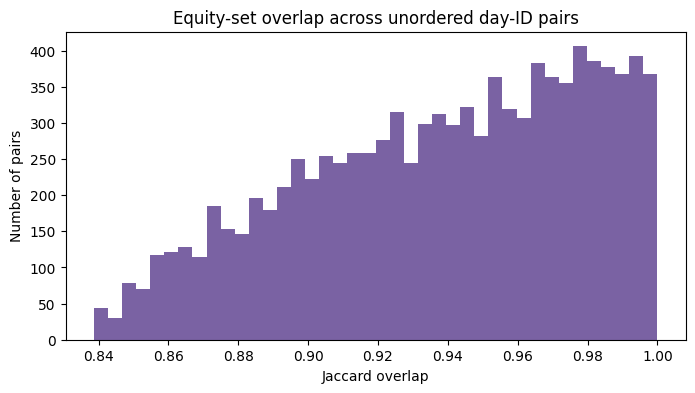

In [3]:
# Cross-identifier membership overlap. This does not assume that day IDs are chronological.
equities_by_day = X_train.groupby('day')['equity'].agg(lambda values: set(values)).sort_index()
day_sets = equities_by_day.tolist()
n_possible_day_pairs = N_DAYS * (N_DAYS - 1) // 2
max_exact_pairs = 50_000
max_sample_pairs = 10_000

if n_possible_day_pairs <= max_exact_pairs:
    day_pair_indices = list(itertools.combinations(range(N_DAYS), 2))
    jaccard_method = f'exact calculation over all {n_possible_day_pairs:,} unordered day-ID pairs'
else:
    rng = np.random.default_rng(20260908)
    sampled = set()
    target_pairs = min(max_sample_pairs, n_possible_day_pairs)
    while len(sampled) < target_pairs:
        pair = tuple(sorted(rng.choice(N_DAYS, size=2, replace=False)))
        sampled.add(pair)
    day_pair_indices = list(sampled)
    jaccard_method = (
        f'reproducible sample of {target_pairs:,} unordered day-ID pairs '
        f'from {n_possible_day_pairs:,} possible pairs (seed=20260908)'
    )

jaccard_values = []
for left, right in day_pair_indices:
    left_set, right_set = day_sets[left], day_sets[right]
    jaccard_values.append(len(left_set & right_set) / len(left_set | right_set))

jaccard_values = pd.Series(jaccard_values, name='jaccard_overlap')
print('Jaccard method:', jaccard_method)
display(compact_describe(jaccard_values).to_frame())
ax = jaccard_values.plot.hist(bins=40, color='#7a62a3', figsize=(8, 4))
ax.set(title='Equity-set overlap across unordered day-ID pairs', xlabel='Jaccard overlap', ylabel='Number of pairs')
plt.show()

,count,proportion
reod,,
-1,253639,0.300770
0,347465,0.412031
1,242195,0.287199


day_class_counts                           day_class_proportions  \
reod                -1            0            1                    -1   
count       503.000000   503.000000   503.000000            503.000000   
mean        504.252485   690.785288   481.500994              0.300850   
std         285.534938   186.445504   258.916389              0.170767   
min           0.000000   131.000000     0.000000              0.000000   
1%            0.480000   190.020000     0.400000              0.000285   
10%         218.000000   463.800000   184.800000              0.129546   
50%         445.000000   716.000000   444.000000              0.263971   
90%         879.000000   836.000000   828.200000              0.525477   
99%        1365.000000  1656.420000  1321.200000              0.823832   
max        1536.000000  1706.000000  1496.000000              0.910492   

                              equity_class_counts                            \
reod            0           1                  -1            0            1   
count  503.000000  503.000000         1829.000000  1829.000000  1829.000000   
mean     0.411923    0.287227          138.676326   189.975396   132.419355   
std      0.110625    0.154723           51.664496    85.494878    49.069835   
min      0.077653    0.000000            0.000000     3.000000     0.000000   
1%       0.115303    0.000237            4.280000    14.560000     4.000000   
10%      0.277681    0.109961           63.000000    91.000000    58.000000   
50%      0.426594    0.263593          151.000000   182.000000   144.000000   
90%      0.500648    0.491651          194.200000   304.000000   186.000000   
99%      0.991221    0.800317          222.000000   448.720000   213.000000   
max      1.000000    0.887307          245.000000   499.000000   250.000000   

      equity_class_proportions                            
reod                        -1            0            1  
count              1829.000000  1829.000000  1829.000000  
mean                  0.298881     0.415189     0.285931  
std                   0.088506     0.164207     0.083665  
min                   0.000000     0.105263     0.000000  
1%                    0.031126     0.159168     0.022257  
10%                   0.178926     0.238291     0.172962  
50%                   0.316103     0.383698     0.300199  
90%                   0.395668     0.642545     0.377734  
99%                   0.454712     0.946322     0.429636  
max                   0.533333     1.000000     0.583333

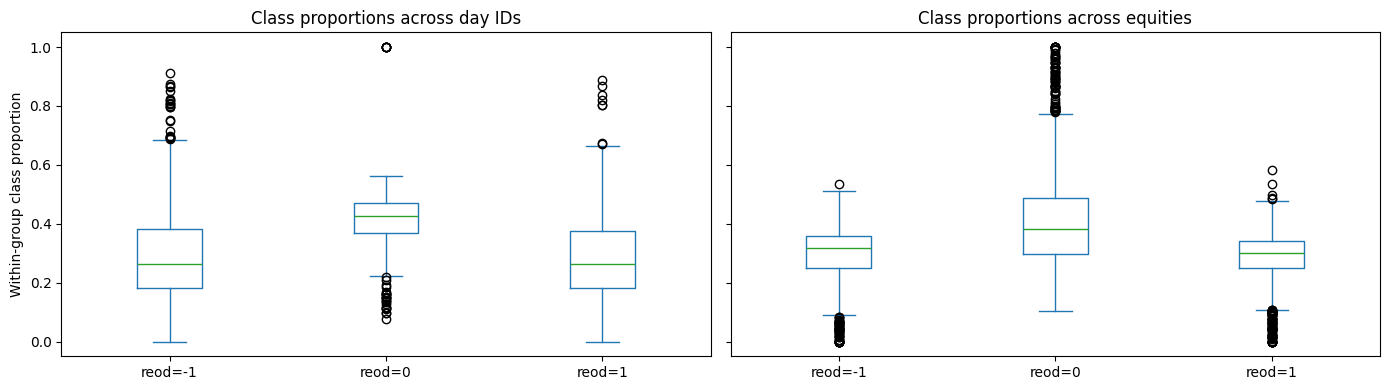

In [4]:
classes = [-1, 0, 1]
global_target_distribution = (
    y_train.value_counts().reindex(classes, fill_value=0).to_frame('count')
    .assign(proportion=lambda frame: frame['count'] / frame['count'].sum())
)
global_target_distribution.index.name = 'reod'
display(global_target_distribution)

def grouped_target_distribution(group_column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    frame = pd.DataFrame({group_column: X_train[group_column], 'reod': y_train})
    counts = pd.crosstab(frame[group_column], frame['reod']).reindex(columns=classes, fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    return counts, proportions

day_target_counts, day_target_proportions = grouped_target_distribution('day')
equity_target_counts, equity_target_proportions = grouped_target_distribution('equity')

target_group_summary = pd.concat({
    'day_class_counts': day_target_counts.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'day_class_proportions': day_target_proportions.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'equity_class_counts': equity_target_counts.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
    'equity_class_proportions': equity_target_proportions.describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]),
}, axis=1)
display(target_group_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
day_target_proportions.rename(columns={-1: 'reod=-1', 0: 'reod=0', 1: 'reod=1'}).plot.box(ax=axes[0])
axes[0].set(title='Class proportions across day IDs', ylabel='Within-group class proportion')
equity_target_proportions.rename(columns={-1: 'reod=-1', 0: 'reod=0', 1: 'reod=1'}).plot.box(ax=axes[1])
axes[1].set(title='Class proportions across equities')
plt.tight_layout()
plt.show()

In [5]:
# Identifier audit only: numeric gaps do not establish chronological meaning.
sorted_day_ids = np.sort(X_train['day'].unique())
day_id_steps = np.diff(sorted_day_ids)
positive_gaps = day_id_steps[day_id_steps > 1]
missing_integer_ids_within_range = int(sorted_day_ids[-1] - sorted_day_ids[0] + 1 - len(sorted_day_ids))

day_id_summary = pd.Series({
    'minimum_day_id': int(sorted_day_ids[0]),
    'maximum_day_id': int(sorted_day_ids[-1]),
    'unique_day_ids': len(sorted_day_ids),
    'integer_ids_missing_within_range': missing_integer_ids_within_range,
    'number_of_non_unit_gaps': len(positive_gaps),
}, name='value').to_frame()
display(day_id_summary)

if len(positive_gaps):
    display(compact_describe(pd.Series(positive_gaps, name='gap_size')).to_frame())
    ax = pd.Series(positive_gaps).plot.hist(bins=min(40, len(np.unique(positive_gaps))), color='#a85d5d', figsize=(8, 4))
    ax.set(title='Sizes of non-unit gaps between sorted day identifiers', xlabel='Identifier gap size', ylabel='Number of gaps')
    plt.show()
else:
    print('No non-unit gaps were found in the sorted numeric day identifiers.')

print('Interpretation constraint: these are identifier properties only; they do not prove chronological ordering or calendar spacing.')

,value
minimum_day_id,0
maximum_day_id,502
unique_day_ids,503
integer_ids_missing_within_range,0
number_of_non_unit_gaps,0


No non-unit gaps were found in the sorted numeric day identifiers.
Interpretation constraint: these are identifier properties only; they do not prove chronological ordering or calendar spacing.


## Intraday returns and missingness

This notebook validates the preprocessing assumptions before training a classifier. In particular, it keeps observed zero returns distinct from missing observations.

In [6]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Open this notebook from the project or notebooks directory.')

sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import (
    ReturnPreprocessor,
    get_return_columns,
    load_training_data,
    summarize_missingness,
)

In [7]:
# X_train, y_train and the return columns were initialized above.
print(f'Rows: {len(X_train):,}')
print(f'Return timestamps: {len(return_columns)}')
display(y_train.value_counts().sort_index().rename('count').to_frame())
display(summarize_missingness(returns).head())

Rows: 843,299
Return timestamps: 53


,count
reod,
-1,253639
0,347465
1,242195


,missing_count,missing_ratio,zero_ratio_observed
return_column,,,
r0,45823,0.054338,0.209071
r1,96815,0.114805,0.160788
r2,102470,0.121511,0.166578
r3,94169,0.111667,0.159994
r4,93730,0.111147,0.167140


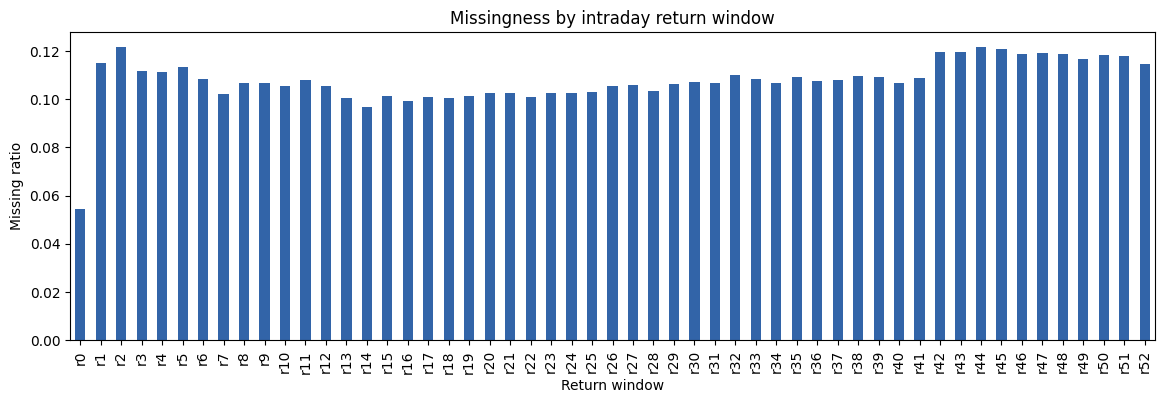

,mean,median,count
reod,,,
-1,0.056461,0.0,253639
0,0.181826,0.0,347465
1,0.054944,0.0,242195


In [8]:
audit = summarize_missingness(returns)
ax = audit['missing_ratio'].plot(kind='bar', figsize=(14, 4), color='#3264a8')
ax.set(title='Missingness by intraday return window', xlabel='Return window', ylabel='Missing ratio')
plt.show()

class_missingness = (
    pd.concat([returns.isna().mean(axis=1).rename('missing_ratio'), y_train], axis=1)
    .groupby('reod')['missing_ratio']
    .agg(['mean', 'median', 'count'])
)
display(class_missingness)

In [9]:
# Baseline representation for tree models: preserve NaNs and add masks.
preprocessor = ReturnPreprocessor(imputation='none', scale=False).fit(X_train)
X_tabular = preprocessor.tabular_inputs(X_train.iloc[:5_000])
sequence_values, observed_mask = preprocessor.sequence_inputs(X_train.iloc[:5_000])

print('Tabular shape:', X_tabular.shape)
print('Sequence values shape:', sequence_values.shape)
print('Observed-mask shape:', observed_mask.shape)

Tabular shape: (5000, 112)
Sequence values shape: (5000, 53)
Observed-mask shape: (5000, 53)


## Decision checkpoint

Before adding a VAE, compare native missing-value handling and median imputation plus masks with leakage-safe validation folds. A more complex imputer is retained only if it improves out-of-fold classification performance, not merely reconstruction error.